In [204]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import warnings
import numpy as np
from scipy.optimize import curve_fit
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
import altair as alt
import importlib
import strategic_approach_helpers as sah   
importlib.reload(sah)

warnings.filterwarnings('ignore')  # Suppress all warnings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
ran = False

In [205]:
def run_query(query, credentials_path):
    """Sends a custom query to BigQuery using a specified credentials file."""
    try:
        credentials = service_account.Credentials.from_service_account_file(credentials_path)
        client = bigquery.Client(credentials=credentials)

        query_job = client.query(query)
        results = query_job.result()
        # Convert RowIterator to DataFrame
        df = results.to_dataframe()

        return df

    except Exception as e:
        print(f"An error occurred: {e}")
        return None
    

def set_multiindex(df):
    """Set index to ['trade_date', 'ticker', 'expirDate']."""
    return df.set_index(['trade_date', 'ticker', 'expirDate']).sort_index()

def get_closest_to_delta(df, target_delta):
    """
    For each (trade_date, ticker, expirDate), find the rows with delta just above and just below target_delta.
    Returns a DataFrame with those rows.
    Assumes df is MultiIndexed by ['trade_date', 'ticker', 'expirDate'].
    """
    def closest_rows(group):
        above = group[group['delta'] >= target_delta].sort_values('delta').head(1)
        below = group[group['delta'] < target_delta].sort_values('delta', ascending=False).head(1)
        return pd.concat([below, above])

    # Group by the MultiIndex levels directly
    return df.groupby(level=['trade_date', 'ticker', 'expirDate'], group_keys=False).apply(closest_rows)

def get_closest_to_delta_abs(df, target_delta):
    """
    For each (trade_date, ticker, expirDate), find the row with delta closest (by absolute difference) to target_delta.
    Returns a DataFrame with those rows (one per group).
    """
    def closest_row(group):
        # Sort by absolute difference, then take the first row only
        return group.iloc[(group['delta'] - target_delta).abs().argsort()[:1]]
    return df.groupby(level=['trade_date', 'ticker', 'expirDate'], group_keys=False).apply(closest_row)


def get_closest_to_price_for_ticker(df, ticker, target_price):
    """
    For a given ticker, find the rows with spot_px just above and just below target_price.
    Returns a DataFrame with those rows.
    Assumes df is MultiIndexed by ['trade_date', 'ticker', 'expirDate'].
    """
    # Filter by ticker using the index
    sub = df[df.index.get_level_values('ticker') == ticker]
    above = sub[sub['spot_px'] >= target_price].sort_values('spot_px').head(1)
    below = sub[sub['spot_px'] < target_price].sort_values('spot_px', ascending=False).head(1)
    return pd.concat([below, above])

def get_ticker_chain_for_expiry(df, ticker, expirDate):
    """
    Returns all rows for a given ticker and expiration date.
    """
    return df.xs((ticker, expirDate), level=['ticker', 'expirDate'])

def get_ticker_all_chains(df, ticker):
    """
    Returns all rows for a given ticker across all expiration dates.
    """
    return df.xs(ticker, level='ticker')

def get_expiries_for_ticker(df, ticker):
    """
    Returns a sorted list of all unique expirDate values for a given ticker.
    """
    return sorted(df.xs(ticker, level='ticker').index.get_level_values('expirDate').unique())

def get_subset_by_tickers(df, tickers):
    """
    Returns a subset of the DataFrame for the specified list of tickers.
    Assumes df is MultiIndexed by ['trade_date', 'ticker', 'expirDate'].
    """
    idx = pd.IndexSlice
    return df.loc[idx[:, tickers, :], :]

def interpolate_constant_maturity_nearest(df, days_list, value_col='smoothSmvVol', yte_col='yte'):
    """
    Interpolates the value_col to constant maturities (in days) for each (trade_date, ticker),
    using only the two expiries closest to each target maturity.
    Returns a DataFrame with index (trade_date, ticker) and columns for each target maturity.
    """
    if df[yte_col].max() < 100:  # crude check for years
        df = df.copy()
        df[yte_col] = df[yte_col] * 365

    results = []
    for (trade_date, ticker), group in df.reset_index().groupby(['trade_date', 'ticker']):
        group = group.sort_values(yte_col)
        x = group[yte_col].values
        y = group[value_col].values
        row = {'trade_date': trade_date, 'ticker': ticker}
        for day in days_list:
            idx = np.searchsorted(x, day)
            # If exact match, use that value
            if idx < len(x) and np.isclose(x[idx], day):
                interp_val = y[idx]
            elif idx == 0:
                interp_val = y[0]
            elif idx == len(x):
                interp_val = y[-1]
            else:
                x0, x1 = x[idx-1], x[idx]
                y0, y1 = y[idx-1], y[idx]
                if x1 == x0:
                    interp_val = y0  # or y1, since they're the same
                else:
                    interp_val = y0 + (y1 - y0) * (day - x0) / (x1 - x0)
            row[f'{value_col}_{int(day)}d'] = interp_val
        results.append(row)
    return pd.DataFrame(results).set_index(['trade_date', 'ticker'])

def get_expiries_nearest_to_constant_maturities(
    df, days_list, yte_col='yte'
):
    """
    For each (trade_date, ticker), finds the expirDate whose yte is closest to each target in days_list.
    Returns a DataFrame filtered to those expiries, with columns:
      - target_day: the target day this expiry is closest to
      - yte_diff: target_day - actual_yte (in days)
    Index is (trade_date, ticker, expirDate).
    """
    if df[yte_col].max() < 100:  # crude check for years
        df = df.copy()
        df[yte_col] = df[yte_col] * 365

    records = []
    for (trade_date, ticker), group in df.reset_index().groupby(['trade_date', 'ticker']):
        group = group.sort_values(yte_col)
        x = group[yte_col].values
        expiries = group['expirDate'].values
        for target_day in days_list:
            idx = np.argmin(np.abs(x - target_day))
            row = group.iloc[idx].copy()
            row['target_day'] = target_day
            row['days_diff'] = int(target_day - x[idx])
            records.append(row)
    result_df = pd.DataFrame(records)
    result_df.set_index(['trade_date', 'ticker', 'expirDate'], inplace=True)
    return result_df


def generate_straddle(df):
    """
    Given a DataFrame with option expiry rows, generate straddle columns and formatting.
    Expects columns: cValue, pValue, delta, stkPx, iRate, yte, gamma, vega.
    Returns a DataFrame with new columns.
    """
    out = df.copy()
    out['said'] = "STDL_" + out['target_day'].astype(str) + "_CD"
    cols = out.columns.tolist()
    cols.insert(0, cols.pop(cols.index('said')))
    out = out[cols]
    out['saval'] = out['cValue'] + out['pValue']
    cols = out.columns.tolist()
    cols.insert(1, cols.pop(cols.index('saval')))
    out = out[cols]
    out['netDelta'] = out['delta'] + (out['delta'] - 1)
    out['dollarDelta'] = out['netDelta'] * out['stkPx']
    out['fwdPx'] = (out['stkPx'] * np.exp(out['iRate'] * out['yte'] / 365)).astype(float)
    out['dollarGamma'] = out['gamma'] * out['fwdPx'] ** 2
    out['rtVega'] = out['vega'] / np.sqrt(out['yte'])
    out['longCall'] = True
    out['longPut'] = True
    return out

In [203]:
query_string = """
    SELECT
        *
    FROM
        `trading-house-1.trading_house_options_all_1.options_all_table_1`
    WHERE trade_date = DATE(2025, 6, 20);
"""

credentials_file_path = "trading-house-1-master.json"  # Replace with your credentials file path
if not ran:
  base_df = run_query(query_string, credentials_file_path)
  base_df = set_multiindex(base_df)
  base_df.sort_values("ticker", inplace=True);  
  ran = True


In [219]:
class StrategicApproach:
    def __init__(self, strategy, trade_date, restriking_interval, tickers=None, base_df=None, credentials_path="trading-house-1-master.json"):
        """
        strategy: str, e.g. "STDL"
        trade_date: str or datetime.date, e.g. "2025-06-23"
        tickers: optional list of str, e.g. ["TSLA", "NVDA", "AAPL"]. If None, use all tickers in data.
        base_df: optional, pre-fetched DataFrame
        credentials_path: path to GCP credentials for BigQuery
        """
        self.strategy = strategy.upper()
        self.trade_date = pd.to_datetime(trade_date).date()
        self.tickers = tickers
        self.restriking_interval = restriking_interval
        self.credentials_path = credentials_path
        self.base_df = base_df
        self.proto_sa_df = None

    def _query_bigquery(self):
        """Queries BigQuery for the options data for the given trade_date."""
        query = f"""
            SELECT *
            FROM `trading-house-1.trading_house_options_all_1.options_all_table_1`
            WHERE trade_date = DATE('{self.trade_date}')
        """
        credentials = service_account.Credentials.from_service_account_file(self.credentials_path)
        client = bigquery.Client(credentials=credentials)
        df = client.query(query).result().to_dataframe()
        return df

    def _prepare_base_df(self):
        """Ensures base_df is loaded and indexed."""
        if self.base_df is None:
            self.base_df = self._query_bigquery()
            # Set MultiIndex
        self.base_df = self.base_df.reset_index()
        self.base_df = self.base_df.set_index(['trade_date', 'ticker', 'expirDate']).sort_index()

    def _generate_straddle(self):
        """Implements the STDL (straddle) strategy."""
        # 1. Filter for tickers if provided, else use all
        if self.tickers is not None:
            idx = pd.IndexSlice
            test_base_df = self.base_df.loc[idx[:, self.tickers, :], :]
        else:
            test_base_df = self.base_df

        # 2. Get ATM options (delta closest to 0.5)
        atm_df = get_closest_to_delta_abs(test_base_df, 0.5)

        # 3. Get expiries nearest to constant maturities
        days_list = [30, 60, 90, 180, 360, 720]
        nearest_expiry_50d_df = get_expiries_nearest_to_constant_maturities(
            atm_df, days_list, yte_col='yte'
        )

        # 4. Generate straddle DataFrame
        proto_sa_df = generate_straddle(nearest_expiry_50d_df)
        return proto_sa_df

    def _add_restriking_interval(self):
        """Implements the STDL (straddle) strategy."""
        # 1. Filter for tickers if provided, else use all
        self.proto_sa_df["said"] = self.proto_sa_df["said"] + "_" + self.restriking_interval
        return self.proto_sa_df

    def generate(self):
        """Runs the full pipeline and returns the proto_sa_df DataFrame, switching on strategy."""
        self._prepare_base_df()

        if self.strategy == "STDL":
            self.proto_sa_df = self._generate_straddle()
        else:
            raise NotImplementedError(f"Strategy '{self.strategy}' is not implemented yet.")

        self._add_restriking_interval()
        return self.proto_sa_df

In [220]:
test_base_df_2 = get_subset_by_tickers(base_df, ['CSX', 'NSC', 'UNP'])
sa = StrategicApproach("STDL", "2025-06-20", restriking_interval="W_RS", tickers=['CSX', 'NSC', 'UNP'], base_df=test_base_df_2)
proto_sa_df = sa.generate()

In [221]:

proto_sa_df

said  saval               cOpra  \
trade_date ticker expirDate                                                 
2025-06-20 CSX    2025-07-18   STDL_30_CD_W_RS   1.82  CSX250718C00032500   
                  2025-08-15   STDL_60_CD_W_RS   2.68  CSX250815C00032500   
                  2025-09-19   STDL_90_CD_W_RS   3.27  CSX250919C00032500   
                  2025-11-21  STDL_180_CD_W_RS   4.33  CSX251121C00032500   
                  2026-06-18  STDL_360_CD_W_RS   6.23  CSX260618C00032500   
                  2027-01-15  STDL_720_CD_W_RS   8.25  CSX270115C00035000   
           NSC    2025-07-18   STDL_30_CD_W_RS  12.51  NSC250718C00250000   
                  2025-08-15   STDL_60_CD_W_RS  20.27  NSC250815C00250000   
                  2025-09-19   STDL_90_CD_W_RS  25.56  NSC250919C00260000   
                  2025-12-19  STDL_180_CD_W_RS  36.08  NSC251219C00260000   
                  2026-06-18  STDL_360_CD_W_RS  50.70  NSC260618C00270000   
                  2027-01-15  STDL_720_CD_W_RS  63.95  NSC270115C00270000   
           UNP    2025-07-18   STDL_30_CD_W_RS  10.48  UNP250718C00225000   
                  2025-08-15   STDL_60_CD_W_RS  16.33  UNP250815C00225000   
                  2025-09-19   STDL_90_CD_W_RS  20.55  UNP250919C00220000   
                  2025-12-19  STDL_180_CD_W_RS  28.99  UNP251219C00225000   
                  2026-06-18  STDL_360_CD_W_RS  40.90  UNP260618C00230000   
                  2027-01-15  STDL_720_CD_W_RS  55.03  UNP270115C00240000   

                                           pOpra  stkPx    yte  strike  cVolu  \
trade_date ticker expirDate                                                     
2025-06-20 CSX    2025-07-18  CSX250718P00032500  32.06  28.00   32.50 562.00   
                  2025-08-15  CSX250815P00032500  32.06  56.00   32.50   9.00   
                  2025-09-19  CSX250919P00032500  32.06  91.00   32.50  13.00   
                  2025-11-21  CSX251121P00032500  32.06 154.00   32.50  29.00   
                  2026-06-18  CSX260618P00032500  32.06 363.00   32.50   0.00   
                  2027-01-15  CSX270115P00035000  32.06 574.00   35.00   0.00   
           NSC    2025-07-18  NSC250718P00250000 253.34  28.00  250.00   0.00   
                  2025-08-15  NSC250815P00250000 253.34  56.00  250.00   7.00   
                  2025-09-19  NSC250919P00260000 253.34  91.00  260.00   2.00   
                  2025-12-19  NSC251219P00260000 253.34 182.00  260.00   0.00   
                  2026-06-18  NSC260618P00270000 253.34 363.00  270.00   0.00   
                  2027-01-15  NSC270115P00270000 253.34 574.00  270.00   0.00   
           UNP    2025-07-18  UNP250718P00225000 222.19  28.00  225.00   3.00   
                  2025-08-15  UNP250815P00225000 222.19  56.00  225.00   3.00   
                  2025-09-19  UNP250919P00220000 222.19  91.00  220.00   1.00   
                  2025-12-19  UNP251219P00225000 222.19 182.00  225.00   0.00   
                  2026-06-18  UNP260618P00230000 222.19 363.00  230.00   0.00   
                  2027-01-15  UNP270115P00240000 222.19 574.00  240.00   0.00   

                                 cOi  pVolu     pOi  cBidPx  cValue  cAskPx  \
trade_date ticker expirDate                                                   
2025-06-20 CSX    2025-07-18 7319.00 164.00 1974.00    0.70    0.76    0.75   
                  2025-08-15 9301.00   3.00  775.00    1.15    1.23    1.30   
                  2025-09-19 5967.00 474.00 2030.00    1.50    1.54    1.60   
                  2025-11-21 1086.00   3.00  624.00    2.10    2.17    2.25   
                  2026-06-18  661.00   0.00 1718.00    3.20    3.31    3.40   
                  2027-01-15  198.00   0.00   15.00    3.00    3.32    3.30   
           NSC    2025-07-18  188.00 182.00  106.00    8.00    8.26    8.70   
                  2025-08-15  108.00   0.00   66.00   11.40   11.95   12.50   
                  2025-09-19  230.00   5.00   31.00    9.80   10.11   10.40   
           

In [111]:
days_list = [30, 60, 90, 180, 360, 720]
cm_df = interpolate_constant_maturity(get_closest_to_delta(test_base_df, 0.5), days_list, value_col='smoothSmvVol', yte_col='yte')
cm_df

smoothSmvVol_30d  smoothSmvVol_60d  smoothSmvVol_90d  \
trade_date ticker                                                         
2025-06-20 AAPL            0.255811          0.295275          0.268206   
           NVDA            0.351017          0.380658          0.418357   
           TSLA            0.618287          0.638610          0.593142   

                   smoothSmvVol_180d  smoothSmvVol_360d  smoothSmvVol_720d  
trade_date ticker                                                           
2025-06-20 AAPL             0.274516           0.263515           0.286417  
           NVDA             0.420492           0.426185           0.413513  
           TSLA             0.598703           0.605594           0.616302

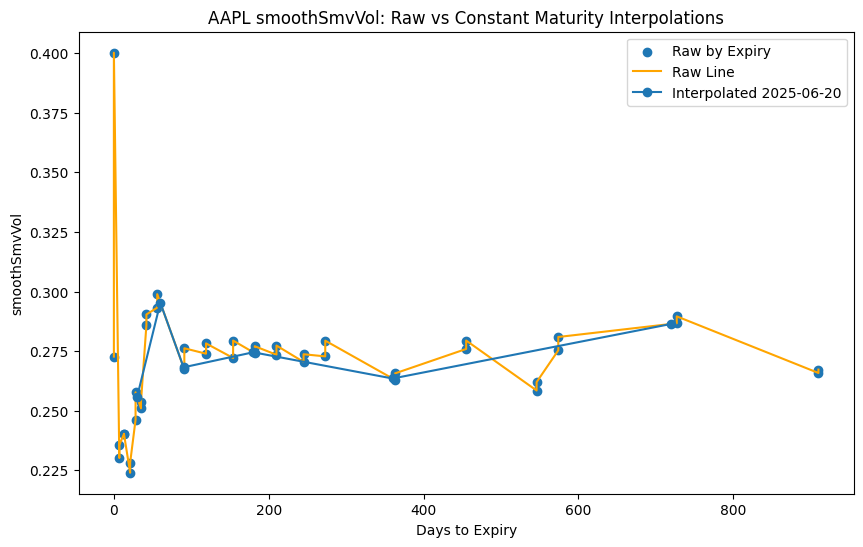

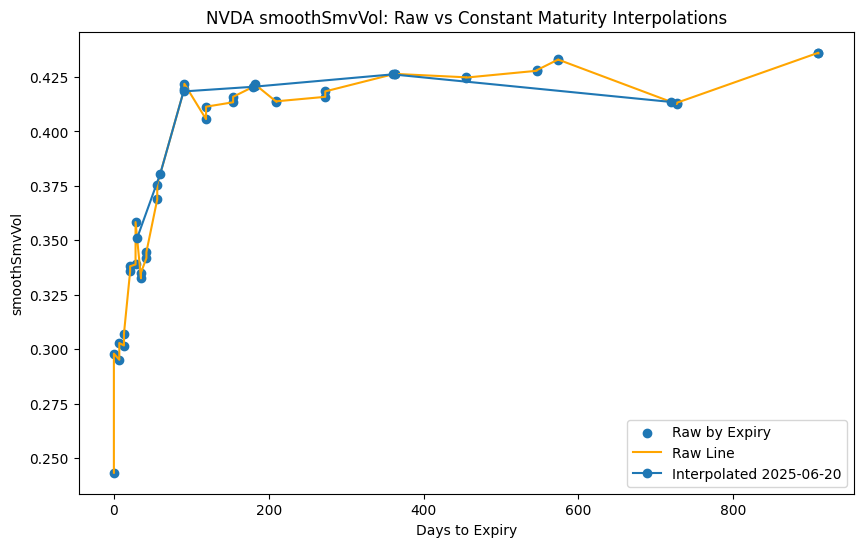

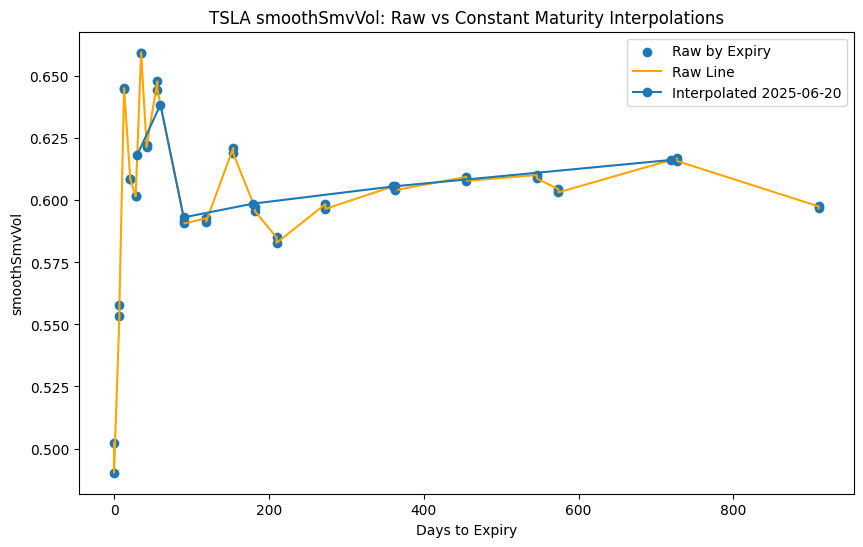

In [149]:
# Get ATM (delta 0.5) for both raw and interpolation
atm_df = get_closest_to_delta(test_base_df, 0.5)
days_list = [30, 60, 90, 180, 360, 720]
cm_df = interpolate_constant_maturity_nearest(atm_df, days_list, value_col='smoothSmvVol', yte_col='yte')

for ticker in atm_df.index.get_level_values('ticker').unique():
    fig, ax = plt.subplots(figsize=(10, 6))
    raw = atm_df.xs(ticker, level='ticker')
    x_raw = (raw['yte'] * 365).values
    y_raw = raw['smoothSmvVol'].values
    sort_idx = np.argsort(x_raw)
    x_raw_sorted = x_raw[sort_idx]
    y_raw_sorted = y_raw[sort_idx]
    ax.scatter(x_raw, y_raw, label='Raw by Expiry', color='tab:blue')
    ax.plot(x_raw_sorted, y_raw_sorted, color='orange', linestyle='-', marker='', label='Raw Line')

    interp_row = cm_df.loc[(slice(None), ticker), :]
    if isinstance(interp_row, pd.DataFrame):
        for idx, row in interp_row.iterrows():
            days = [int(col.split('_')[-1][:-1]) for col in row.index]
            vals = row.values
            ax.plot(days, vals, marker='o', linestyle='-', label=f'Interpolated {idx[0]}')
    else:
        days = [int(col.split('_')[-1][:-1]) for col in interp_row.index]
        vals = interp_row.values
        ax.plot(days, vals, marker='o', linestyle='-', label='Interpolated')

    ax.set_title(f"{ticker} smoothSmvVol: Raw vs Constant Maturity Interpolations")
    ax.set_xlabel("Days to Expiry")
    ax.set_ylabel("smoothSmvVol")
    ax.legend()
    plt.show();